# TP 2 - Préparation de la base RAG


---
## 0. Configuration partagée


Cahier de préparation des données. La qualité de la chaîne RAG dépend directement du découpage des documents. Ici, on construit une version de base (V1) qui servira de point de comparaison.

In [ ]:
from shared.config import ROOT_DIR
from shared.rag_utils import (
    rag_load_markdown_documents,
    rag_chunk_documents_by_chars,
    rag_describe_chunks,
    rag_build_chunk_embeddings,
    rag_index_chunks_chroma,
)

DATA_DIR = ROOT_DIR / "TP2_travel_planner_RAG" / "data"
MARKDOWN_DIR = DATA_DIR / "guides_markdown"
CHROMA_DIR_V1 = DATA_DIR / "chroma_db_rag_v1"

---
## 1. Charger les documents


**TODO — `rag_load_markdown_documents`**

Fichier à modifier : `shared/rag_utils.py`

La base RAG se construit à partir de documents Markdown. Cette étape sert à charger une liste de documents homogène pour la suite du TP

`rag_load_markdown_documents` : fonction qui lit les fichiers Markdown d'un dossier et retourne une liste de `MarkdownDocument` avec `source` et `text`


In [ ]:
# TODO : charger les markdowns dans une structure uniforme {source, text}
documents = rag_load_markdown_documents(MARKDOWN_DIR)

total_documents = len(documents)
total_characters = sum(len(document["text"]) for document in documents)

print(f"Documents Markdown chargés : {total_documents}")
print(f"Nombre total de caractères : {total_characters}")

---
## 2. Stratégie de découpage V1


**TODO — `rag_chunk_documents_by_chars`**

Fichier à modifier : `shared/rag_utils.py`

Un document complet est trop long pour la recherche. On le découpe en morceaux de taille comparable, mesurés en nombre de caractères
L'overlap garde une zone de texte partagée entre deux chunks voisins pour conserver la continuité

`rag_chunk_documents_by_chars` : fonction qui découpe chaque `MarkdownDocument` en `RAGChunk` avec une fenêtre glissante de taille fixe et overlap, en redémarrant `chunk_id` à 0 pour chaque document

Repère attendu : entre 100 et 500 chunks au total sur l'ensemble des documents

Après exécution, vérifie la distribution des tailles de chunks dans la cellule d'inspection

Cette V1 est la référence de comparaison avant la V2 orientée structure dans le notebook `2_3`


In [ ]:
# TODO : découper chaque document avec fenêtre glissante + overlap

chunks_v1 = rag_chunk_documents_by_chars(
    documents=documents,
    chunk_chars=3000,
    chunk_overlap_chars=250,
)

### Inspection: chunks V1 (`rag_describe_chunks`)

`rag_describe_chunks` est une fonction de contrôle : statistiques + visualisations.
Elle permet de vérifier immédiatement si les chunks sont de bonne taille et bien repartis parmi les documents.

Exemple de statistiques à afficher :
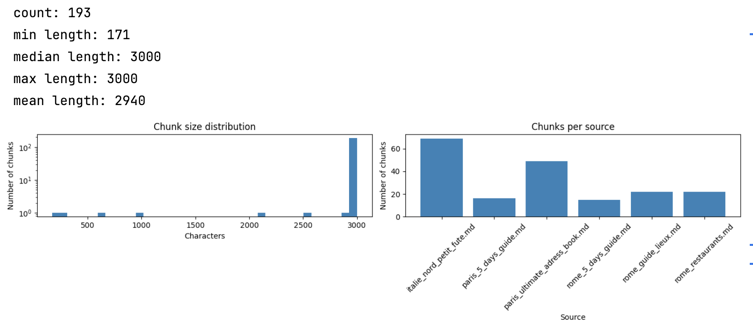

In [ ]:
rag_describe_chunks(chunks_v1)

In [ ]:
sample_indices = [0, len(chunks_v1) // 4, len(chunks_v1) // 2, 3 * len(chunks_v1) // 4, len(chunks_v1) - 1]

for idx in sample_indices:
    chunk = chunks_v1[idx]
    print(f"-- Chunk #{chunk.chunk_id} | source: {chunk.source} | {len(chunk.text)} caractères ---")
    print(chunk.text[:500])
    print("..." if len(chunk.text) > 500 else "")
    print("\n\n\n")

---
## 3. Vectorisation et indexation


**TODO — `rag_build_chunk_embeddings` et `rag_index_chunks_chroma`**

Fichier à modifier : `shared/rag_utils.py`

Après le découpage, chaque chunk doit être transformé en vecteur pour pouvoir être recherché dans Chroma

`rag_build_chunk_embeddings` : fonction qui calcule les embeddings de tous les `RAGChunk`

`rag_index_chunks_chroma` : fonction qui reconstruit la base Chroma V1 en stockant textes, ids, embeddings et métadonnées (`source`, `chunk_id`)


### V1 — Vectorisation et indexation

In [ ]:
# TODO : vectoriser les chunks en batch sans casser l'alignement chunk-vecteur
chunk_embeddings_v1 = rag_build_chunk_embeddings(
    chunks=chunks_v1,
    batch_size=16
)

In [ ]:
# TODO : indexer dans Chroma avec ids + metadata traçables
rag_index_chunks_chroma(persist_dir=CHROMA_DIR_V1, chunks=chunk_embeddings_v1)

print(f"V1 — Chunks indexés : {len(chunk_embeddings_v1)}")
print(f"V1 — Dimension des embeddings : {len(chunk_embeddings_v1[0].embedding)}")
